# Bachelier Average Rate Caplet — Formula Verification

Verify the Bachelier avg rate pricing formula works correctly:
$$PV = T \cdot P(0,T) \cdot \left[(F-K)\Phi(d) + \sigma \hat{g}\,\varphi(d)\right], \quad \hat{g} = \sqrt{T/3}, \quad d = \frac{F-K}{\sigma\hat{g}}$$

**Scope**: round-trip tests, error surface diagnostics, forward rate checks.  
Pricing functions imported from `caplet_vol_surface.py` — no duplication.

In [ ]:
import pandas as pd, numpy as np, torch
from pathlib import Path
from scipy.stats import norm
import sys, os
sys.path.insert(0, '..')       # docs/quant/ap  → caplet_vol_surface
sys.path.insert(0, '../..')    # docs/quant     → pyquant
from caplet_vol_surface import (
    bachelier_caplet_price, implied_vol_avg_rate,
    fast_simulate, theta_to_vec, batch_price_caplets, rho_to_vec
)
from pyquant.interest_rates import build_fwd_curve, build_ifwd_curve_from_now_starting
from pyquant.torch_spline import PchipSpline1D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load market data & build curves ──────────────────────────────────────
data_dir = Path('../../../../data')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')
fwd_ois     = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')

key_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32))
ois_fwd_spline = build_fwd_curve(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32))
key_ifwd_spline = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_key_rate['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_key_rate['time_to_maturity'].values, dtype=torch.float32))
ois_ifwd_spline = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_ois['forward_rate'].values, dtype=torch.float32),
    torch.tensor(fwd_ois['time_to_maturity'].values, dtype=torch.float32))

# ── Timeline + instantaneous forwards ────────────────────────────────────
T_MAX, N_STEPS = 10.0, 3651
timeline = torch.linspace(0, T_MAX, N_STEPS + 1, dtype=torch.float32, device=device)
dt = timeline[1] - timeline[0]
dt_v = dt.item()

I_key = key_ifwd_spline.evaluate(timeline.cpu()).to(device)
I_ois = ois_ifwd_spline.evaluate(timeline.cpu()).to(device)
f_key_vec = torch.zeros_like(timeline)
f_key_vec[:-1] = torch.diff(I_key) / dt; f_key_vec[-1] = f_key_vec[-2]
f_ois_vec = torch.zeros_like(timeline)
f_ois_vec[:-1] = torch.diff(I_ois) / dt; f_ois_vec[-1] = f_ois_vec[-2]

# ── Caplet grid ───────────────────────────────────────────────────────────
caplet_data = vol_key_rate[['time_to_maturity', 'strike', 'implied_normal_vol']].values
T_fixes  = torch.tensor(caplet_data[:, 0], dtype=torch.float32, device=device)
strikes  = torch.tensor(caplet_data[:, 1], dtype=torch.float32, device=device)
market_vols = torch.tensor(caplet_data[:, 2], dtype=torch.float32, device=device)
idx_fixes = torch.searchsorted(timeline, T_fixes).clamp(0, len(timeline)-1)
idx_pays  = torch.searchsorted(timeline, T_fixes + 0.25).clamp(0, len(timeline)-1)
market_fwds = key_ifwd_spline.evaluate(T_fixes.cpu()).to(device) / T_fixes
market_fwds_period = key_fwd_spline.evaluate(T_fixes.cpu()).to(device)

print(f'Loaded {len(T_fixes)} caplets, device={device}, dt={dt_v*365:.1f} days')

Loaded 495 caplets, device=cuda, dt=1.0 days


## 1. Round-Trip Test: σ → Price → σ

In [ ]:
# Round-trip at ACTUAL market strikes (near ATM) for each maturity
print(f"{'T':>6s} {'K':>6s} {'F':>7s} {'σ_in':>7s} {'PV(bp)':>10s} {'σ_out':>10s} {'err':>10s}")
print('-' * 65)

# Pick mid-strike caplet for each unique maturity
for T_test in sorted(set(T_fixes.cpu().numpy())):
    mask = (T_fixes - T_test).abs() < 0.01
    idxs = mask.nonzero().squeeze()
    if idxs.dim() == 0: idxs = idxs.unsqueeze(0)
    ci = idxs[len(idxs)//2].item()  # mid-strike ≈ ATM
    T = T_fixes[ci].item(); K = strikes[ci].item(); F = market_fwds[ci].item()
    sigma_in = market_vols[ci].item()
    idx_T_ = min(int(T / dt_v), len(f_ois_vec) - 1)
    disc = torch.exp(-f_ois_vec[:idx_T_+1].sum() * dt_v).item()
    pv = bachelier_caplet_price(F, K, T, sigma_in, disc)
    sigma_out = implied_vol_avg_rate(F, K, T, pv, disc)
    err = abs(sigma_out - sigma_in) if not np.isnan(sigma_out) else float('nan')
    lbl = f'{T:.1f}Y' if T >= 1 else f'{T*12:.0f}M'
    print(f"{lbl:>6s} {K*100:>5.0f}% {F*100:>6.1f}% {sigma_in*100:>6.2f}% {pv*10000:>9.4f} "
          f"{sigma_out*100:>9.6f}% {err:.2e}")

     T      K       F    σ_in     PV(bp)      σ_out        err
-----------------------------------------------------------------
    1M    12%   15.9%   2.80%   27.8496  2.803751% 3.49e-06
    2M    12%   15.8%   2.54%   54.2658  2.544200% 1.58e-10
    3M    12%   15.8%   2.22%   79.3690  2.221600% 2.71e-11
    6M    12%   15.7%   2.64%  147.8453  2.643100% 1.26e-10
    9M    12%   14.8%   3.22%  159.1240  3.221500% 1.30e-13
  1.0Y    12%   14.1%   3.38%  159.8334  3.384000% 2.14e-12
  2.0Y    12%   12.0%   3.31%  131.2510  3.315000% 1.46e-14
  3.0Y    12%   10.9%   3.13%  133.3883  3.132500% 9.02e-17
  4.0Y    12%   10.2%   3.01%  141.5906  3.011000% 1.88e-14
  5.0Y    12%    9.6%   2.90%  148.2781  2.897900% 8.67e-17
  6.0Y    12%    9.2%   2.81%  156.2018  2.813600% 3.74e-12
  7.0Y    12%    8.8%   2.74%  163.3009  2.743000% 1.89e-13
  8.0Y    12%    8.4%   2.70%  174.1895  2.702900% 2.33e-11
  9.0Y    12%    8.1%   2.67%  185.2689  2.670300% 4.51e-17
 10.0Y    12%    7.9%   2.63%  

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: θ(t) PCHIP spline
t_fine = torch.linspace(0, float(timeline[-1]), 500, device=device)
theta_spline = PchipSpline1D(theta_nodes_t, theta_init)
theta_fine = theta_spline.evaluate(t_fine).detach().cpu().numpy()
t_fine_np = t_fine.cpu().numpy()

ax = axes[0]
ax.plot(t_fine_np, theta_fine * 100, 'b-', linewidth=2, label='θ(t) PCHIP')
ax.plot(theta_nodes_t.cpu().numpy(), np.array(theta_init_list) * 100, 'ro', markersize=8,
        zorder=5, label='θ nodes')
ax.set_xlabel('Time (Y)'); ax.set_ylabel('θ (× 100)')
ax.set_title('θ(t) PCHIP Interpolation'); ax.legend(); ax.grid(True, alpha=0.3)

# Panel 2: √θ(t) as instantaneous vol level
ax = axes[1]
ax.plot(t_fine_np, np.sqrt(np.maximum(theta_fine, 0)) * 100, 'b-', linewidth=2, label='√θ(t)')
ax.plot(theta_nodes_t.cpu().numpy(), np.sqrt(np.array(theta_init_list)) * 100, 'ro',
        markersize=8, zorder=5, label='√θ nodes')
# Overlay market ATM vols at each maturity
atm_Ts, atm_vols = [], []
for T_m in sorted(np.unique(_mkt_T_np)):
    F_T = key_ifwd_spline.evaluate(torch.tensor([T_m])).item() / T_m
    mask = np.abs(_mkt_T_np - T_m) < 0.01
    if mask.sum() > 0:
        mon = np.abs(_mkt_K_np[mask] - F_T)
        atm_vols.append(_mkt_vols_np[np.where(mask)[0][np.argmin(mon)]])
        atm_Ts.append(T_m)
ax.plot(atm_Ts, np.array(atm_vols) * 100, 'k^', markersize=6, label='Market ATM σ_B')
ax.set_xlabel('Time (Y)'); ax.set_ylabel('Vol (%)')
ax.set_title('√θ(t) vs Market ATM Vols'); ax.legend(); ax.grid(True, alpha=0.3)

# Panel 3: predicted model σ_B = √(θ · corr) vs market ATM
ax = axes[2]
pred_Ts = theta_nodes_t.cpu().numpy()
pred_vols = np.sqrt(np.array(theta_init_list) * np.array(corrs)) * 100
ax.plot(pred_Ts, pred_vols, 'bs-', markersize=8, linewidth=2, label='Model σ_B = √(θ·corr)')
ax.plot(atm_Ts, np.array(atm_vols) * 100, 'k^-', markersize=6, linewidth=1, label='Market ATM σ_B')
ax.set_xlabel('Time (Y)'); ax.set_ylabel('Normal Vol (%)')
ax.set_title('Predicted vs Market ATM Vols'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Calibrated HW-Heston: λ={lam_init}, κ={kappa_init}, ε={eps_init}, '
             f'ρ={rho_vx_init}, γ={gamma_init}, ξ={xi_init}, v₀={v0_init:.6f}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Parameter table
print("θ nodes and derived quantities:")
print(f"{'t':>6s} {'θ':>10s} {'√θ (%)':>10s} {'corr(λ,T)':>10s} {'σ_B (%)':>10s}")
print("-" * 50)
for i, tn in enumerate(theta_nodes_t.cpu().numpy()):
    th = theta_init_list[i]
    c = corrs[i]
    print(f"{tn:>6.2f} {th:>10.6f} {np.sqrt(th)*100:>10.4f} {c:>10.4f} {np.sqrt(th*c)*100:>10.4f}")

## 4. Forward Rate: F_avg vs F_period

Two different "forward rates" exist:
- **$F_{\text{period}}(T)$** — simple period rate from market: $P(0,T) = \frac{1}{1+T \cdot F_{\text{period}}}$
- **$F_{\text{avg}}(T) = I(0,T)/T$** — average instantaneous forward: $I(0,T) = -\ln P(0,T) = \int_0^T f(0,t)\,dt$

They differ because $-\ln(1+Tx)/(Tx) < 1$ for $x > 0$.

**Calibration and MC both use $F_{\text{avg}}$** because the caplet payoff is $\max(\int_0^T a_t\,dt - TK,\, 0)$ and $E[\int a_t\,dt] = I(0,T) = T \cdot F_{\text{avg}}$.

In [ ]:
# Step-by-step calculation of both forward rates
print("HOW EACH FORWARD IS COMPUTED (example: T=1Y)")
print("=" * 65)

T_ex = 1.0
# 1. Period forward from market data
F_period = key_fwd_spline.evaluate(torch.tensor([T_ex])).item()
print(f"\n1) F_period(T={T_ex}) = {F_period*100:.4f}%   ← from market forward curve")

# 2. ZCB price
P = 1.0 / (1.0 + T_ex * F_period)
print(f"2) P(0,T) = 1/(1 + T·F_period) = 1/(1 + {T_ex}×{F_period:.4f}) = {P:.6f}")

# 3. Integrated forward
I_0T = -np.log(P)
print(f"3) I(0,T) = −ln P(0,T) = −ln({P:.6f}) = {I_0T:.6f}")

# 4. Average instantaneous forward
F_avg = I_0T / T_ex
print(f"4) F_avg  = I(0,T)/T = {I_0T:.6f}/{T_ex} = {F_avg*100:.4f}%")

# 5. Verify against spline
F_avg_spline = (key_ifwd_spline.evaluate(torch.tensor([T_ex])).item()) / T_ex
print(f"   Check: key_ifwd_spline({T_ex})/T = {F_avg_spline*100:.4f}%  ✓")

print(f"\n   Gap: F_avg − F_period = {(F_avg - F_period)*100:+.4f}%")
print(f"   Because −ln(1+x)/x < 1 for x>0 (Jensen's inequality)")

# Full table across maturities
print(f"\n{'T':>6s} {'F_period':>10s} {'P(0,T)':>10s} {'I(0,T)':>10s} {'F_avg':>10s} {'gap':>8s}")
print('-' * 58)
for T_v in [0.083, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]:
    mask = (T_fixes - T_v).abs() < 0.02
    if not mask.any(): continue
    idx_t = mask.nonzero()[0][0].item()
    fp = market_fwds_period[idx_t].item()
    fa = market_fwds[idx_t].item()
    P_v = 1.0 / (1.0 + T_v * fp)
    I_v = -np.log(P_v)
    lbl = f'{T_v:.1f}Y' if T_v >= 1 else f'{T_v*12:.0f}M'
    print(f"{lbl:>6s} {fp*100:>9.2f}% {P_v:>9.4f} {I_v:>9.4f} {fa*100:>9.2f}% {(fa-fp)*100:>+7.2f}%")

print(f"\n── WHICH RATE IS USED WHERE ──")
print(f"  MC payoff:   max(∫₀ᵀ aₜ dt − T·K, 0)  → underlying is ∫aₜdt, ATM = I(0,T)")
print(f"  Bachelier F: I(0,T)/T = F_avg           → average instantaneous forward")
print(f"  F_period:    only used to compute P(0,T) for discounting")
print(f"  ✓ Calibration uses F_avg everywhere — consistent")

HOW EACH FORWARD IS COMPUTED (example: T=1Y)

1) F_period(T=1.0) = 15.1600%   ← from market forward curve
2) P(0,T) = 1/(1 + T·F_period) = 1/(1 + 1.0×0.1516) = 0.868357
3) I(0,T) = −ln P(0,T) = −ln(0.868357) = 0.141152
4) F_avg  = I(0,T)/T = 0.141152/1.0 = 14.1152%
   Check: key_ifwd_spline(1.0)/T = 14.1152%  ✓

   Gap: F_avg − F_period = -1.0448%
   Because −ln(1+x)/x < 1 for x>0 (Jensen's inequality)

     T   F_period     P(0,T)     I(0,T)      F_avg      gap
----------------------------------------------------------
    1M     16.02%    0.9869    0.0132     15.89%   -0.13%
    3M     16.12%    0.9613    0.0395     15.80%   -0.32%
    6M     16.33%    0.9245    0.0785     15.70%   -0.63%
  1.0Y     15.16%    0.8684    0.1412     14.12%   -1.04%
  2.0Y     13.52%    0.7872    0.2393     11.97%   -1.55%
  3.0Y     12.93%    0.7205    0.3278     10.93%   -2.00%
  5.0Y     12.40%    0.6173    0.4824      9.65%   -2.75%
  7.0Y     12.14%    0.5406    0.6151      8.79%   -3.35%
 10.0Y    

## 6. Calibrated HW-Heston Vol Surface

Run MC simulation with calibrated SPSA v6 parameters (stochastic vol ON) and compare the resulting
implied vol surface to the market.

Key parameters:
- $\varepsilon = 0.274$ (vol-of-vol), $\rho_{vx} = +0.267$ (positive rate-vol correlation)
- $\kappa = 3.25$, $\lambda = 0.219$, $\gamma = 0.5$, $\xi = 0.01$
- $\theta(T)$ solved from median market $\sigma^2$ with OU integral variance correction

### 6a. Calibrated Parameters & MC Simulation

Build $\theta(T)$ from median market ATM $\sigma^2$ near each node (with OU damping correction),
anchor at $t=0$ to prevent PCHIP extrapolation, then run 100k paths (antithetic) with
$\varepsilon = 0.274$, $\rho_{vx} = 0.267$ — stochastic vol active.

In [ ]:
import gc, time

# ── θ nodes anchored at t=0 (prevents PCHIP extrapolation artefacts) ─────
theta_nodes_t = torch.tensor([0.0, 0.25, 0.5, 1.0, 3.0, 5.0, 10.0], dtype=torch.float32, device=device)
rho_nodes_t   = torch.tensor([1.0, 5.0, 10.0], dtype=torch.float32, device=device)

_mkt_T_np   = caplet_data[:, 0]
_mkt_K_np   = caplet_data[:, 1]
_mkt_vols_np = caplet_data[:, 2]

# Calibrated parameters from SPSA v6 — stochastic vol ON
lam_init   = 0.219     # OU mean-reversion speed
kappa_init = 3.25      # CIR mean-reversion speed
eps_init   = 0.274     # CIR vol-of-vol
gamma_init = 0.5       # spread OU mean-reversion
xi_init    = 0.01      # spread vol (constrained to force variance through Heston channel)
rho_vx_init = 0.267    # correlation x ↔ v (positive = rates rise when vol rises)

def ou_avg_rate_correction(lam, T):
    """OU integral variance correction: σ²_B = θ · factor(λ,T).
    factor = (3/T³) · [T/λ² − 2(1−e^{−λT})/λ³ + (1−e^{−2λT})/(2λ³)]"""
    if lam * T < 1e-6:
        return 1.0
    t1 = T / (lam ** 2)
    t2 = 2.0 * (1.0 - np.exp(-lam * T)) / (lam ** 3)
    t3 = (1.0 - np.exp(-2.0 * lam * T)) / (2.0 * lam ** 3)
    return (3.0 / T ** 3) * (t1 - t2 + t3)

# ── Solve θ analytically: θ(T) = σ²_ATM / corr(λ, T) ────────────────────
theta_init_list = []
for tn in theta_nodes_t.cpu().numpy():
    T_eff = max(tn, 0.01)
    F_tn = key_ifwd_spline.evaluate(torch.tensor([T_eff])).item() / T_eff
    mask_t = np.abs(_mkt_T_np - tn) < max(0.15, max(tn, 0.1) * 0.3)
    if mask_t.sum() > 0:
        moneyness = np.abs(_mkt_K_np[mask_t] - F_tn)
        atm_idx = np.where(mask_t)[0][np.argmin(moneyness)]
        sigma_target = _mkt_vols_np[atm_idx]
    else:
        sigma_target = np.median(_mkt_vols_np)
    corr = ou_avg_rate_correction(lam_init, T_eff)
    theta_needed = sigma_target ** 2 / max(corr, 0.01)
    theta_init_list.append(np.clip(theta_needed, 0.0002, 0.05))

# Anchor: t=0 node = t=0.25 node (no downward extrapolation)
theta_init_list[0] = theta_init_list[1]

theta_init = torch.tensor(theta_init_list, dtype=torch.float32, device=device)
theta_vec_init = theta_to_vec(theta_init, theta_nodes_t, timeline)
v0_init = theta_init_list[0]

print("Calibrated HW-Heston parameters (SPSA v6 baseline):")
print(f"  θ nodes  = {theta_nodes_t.cpu().numpy()}")
print(f"  √θ (%)   = {np.sqrt(np.array(theta_init_list))*100}")
corrs = [ou_avg_rate_correction(lam_init, max(t, 0.01)) for t in theta_nodes_t.cpu().numpy()]
print(f"  OU corr  = {[f'{c:.3f}' for c in corrs]}")
print(f"  → model σ_B ≈ √(θ·corr) = {np.sqrt(np.array(theta_init_list)*np.array(corrs))*100} (%)")
print(f"  v0={v0_init:.6f}, κ={kappa_init}, ε={eps_init}, λ={lam_init}")
print(f"  γ={gamma_init}, ξ={xi_init}, ρ_vx={rho_vx_init}")
print(f"  theta_vec[t=0] = {theta_vec_init[0].item():.6f} (√={np.sqrt(theta_vec_init[0].item())*100:.2f}%)")

# ── MC: 100k paths, antithetic ───────────────────────────────────────────
n_paths_mc = 100000
t0 = time.time()
key_paths_init, ois_paths_init, v_paths_init = fast_simulate(
    n_paths_mc, timeline, theta_vec_init, eps_init, v0_init, kappa_init, lam_init,
    gamma_init, xi_init, f_key_vec, f_ois_vec, device,
    seed=42, rho_vx=rho_vx_init, antithetic=True
)

# T-forward measure pricing: returns (PV, F_model, P_model)
# PV = E[disc × payoff]  (exact money-market price)
# F_model = E^T[ā]       (model forward — Jensen guarantees undiscounted ≥ intrinsic)
# P_model = E[disc]       (model ZCB — used to strip discounting in Bachelier inversion)
model_pvs_init, F_model_init, P_model_init = batch_price_caplets(
    key_paths_init, ois_paths_init, timeline,
    idx_fixes, idx_pays, strikes, 0.25, device
)
elapsed = time.time() - t0
print(f"\nMC done: {n_paths_mc} paths (antithetic), T-forward measure, {elapsed:.1f}s")
print(f"Model PVs: min={model_pvs_init.min().item():.6f}, max={model_pvs_init.max().item():.6f}")
print(f"P_model range: [{P_model_init.min().item():.4f}, {P_model_init.max().item():.4f}]")
print(f"F_model range: [{F_model_init.min().item()*100:.2f}%, {F_model_init.max().item()*100:.2f}%]")

# Free paths
del key_paths_init, ois_paths_init, v_paths_init
gc.collect(); torch.cuda.empty_cache()

Calibrated HW-Heston parameters (SPSA v6 baseline):
  θ nodes  = [ 0.    0.25  0.5   1.    3.    5.   10.  ]
  √θ (%)   = [2.18140614 2.18140614 3.38207324 3.8474591  3.667862   3.7711721
 4.29255709]
  OU corr  = ['0.998', '0.962', '0.922', '0.851', '0.629', '0.476', '0.259']
  → model σ_B ≈ √(θ·corr) = [2.17961577 2.1397     3.2471     3.5499     2.9084     2.6006
 2.1855    ] (%)
  v0=0.000476, κ=3.25, ε=0.274, λ=0.219
  γ=0.5, ξ=0.01, ρ_vx=0.267
  theta_vec[t=0] = 0.000476 (√=2.18%)

MC done: 100000 paths (antithetic), T-forward measure, 0.9s
Model PVs: min=0.000000, max=0.187984
P_model range: [0.5114, 0.9868]
F_model range: [5.61%, 15.89%]


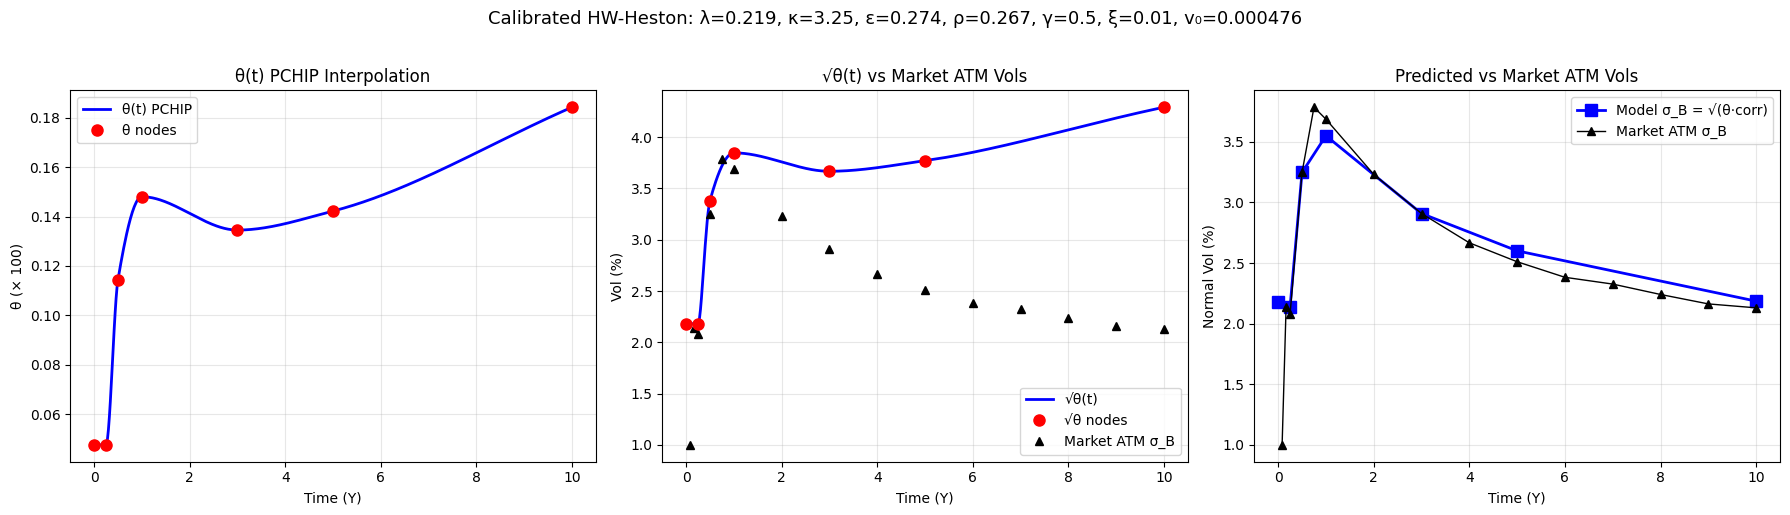

θ nodes and derived quantities:
     t          θ     √θ (%)  corr(λ,T)    σ_B (%)
--------------------------------------------------
  0.00   0.000476     2.1814     0.9984     2.1796
  0.25   0.000476     2.1814     0.9621     2.1397
  0.50   0.001144     3.3821     0.9218     3.2471
  1.00   0.001480     3.8475     0.8513     3.5499
  3.00   0.001345     3.6679     0.6288     2.9084
  5.00   0.001422     3.7712     0.4755     2.6006
 10.00   0.001843     4.2926     0.2592     2.1855


### 6b. Model vs Market Vol Surface

Invert model MC prices back to Bachelier implied vols and compare to market.
Calibrated HW-Heston with $\varepsilon=0.274$, $\rho=+0.267$ should produce **skewed smiles** matching market shape.

ROUND-TRIP: market σ → bachelier_price → σ_out (stable TV channel)
  Total:     495
  Valid:     495/495 (100.0%)
  Via TV:    495  (time-value channel — handles deep ITM)
  Via PV:    0  (standard price channel)
  Max err:   0.000000%
  Mean err:  0.00000000%
  RMSE:      0.00000001%

     T   K(%)   F(%)    m/n%   σ_in%   σ_out%        err meth
--------------------------------------------------------------
  7.0Y    14%   8.8%    +54%   2.87%  2.8670% 2.49e-10   TV
  3.0Y    13%  10.9%    +19%   3.21%  3.2092% 2.47e-10   TV
    1M    28%  15.9%    +73%   3.89%  3.8890% 2.46e-10   TV
 10.0Y    17%   7.9%   +116%   3.16%  3.1619% 2.44e-10   TV
    1M    17%  15.9%     +7%   1.41%  1.4066% 2.42e-10   TV
    1M    20%  15.9%    +26%   2.38%  2.3752% 2.34e-10   TV
    6M    12%  15.7%    -27%   2.52%  2.5151% 2.32e-10   TV
  6.0Y     3%   9.2%    -67%   1.74%  1.7397% 2.31e-10   TV
  9.0Y    17%   8.1%   +109%   3.22%  3.2161% 2.31e-10   TV
    2M     6%  15.9%    -62%   5.74%  5.7431% 2.

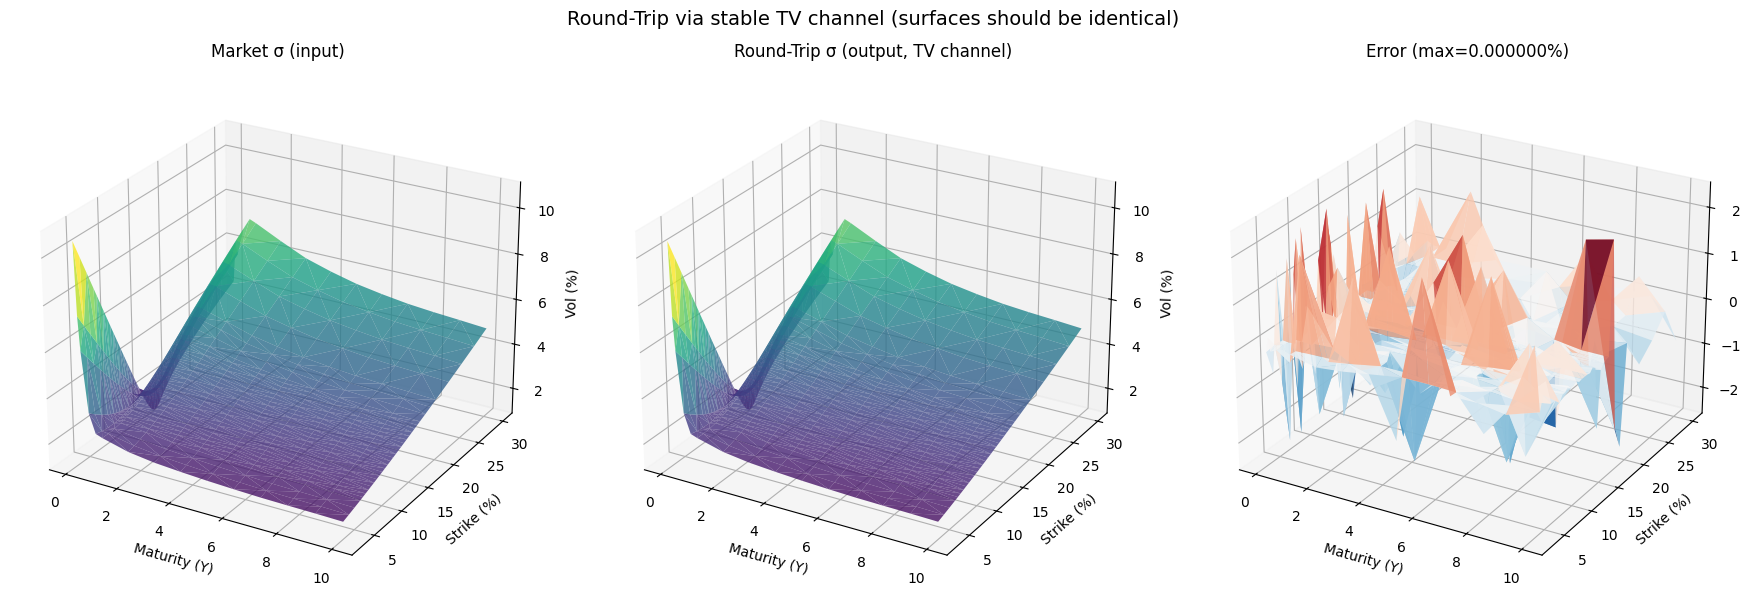

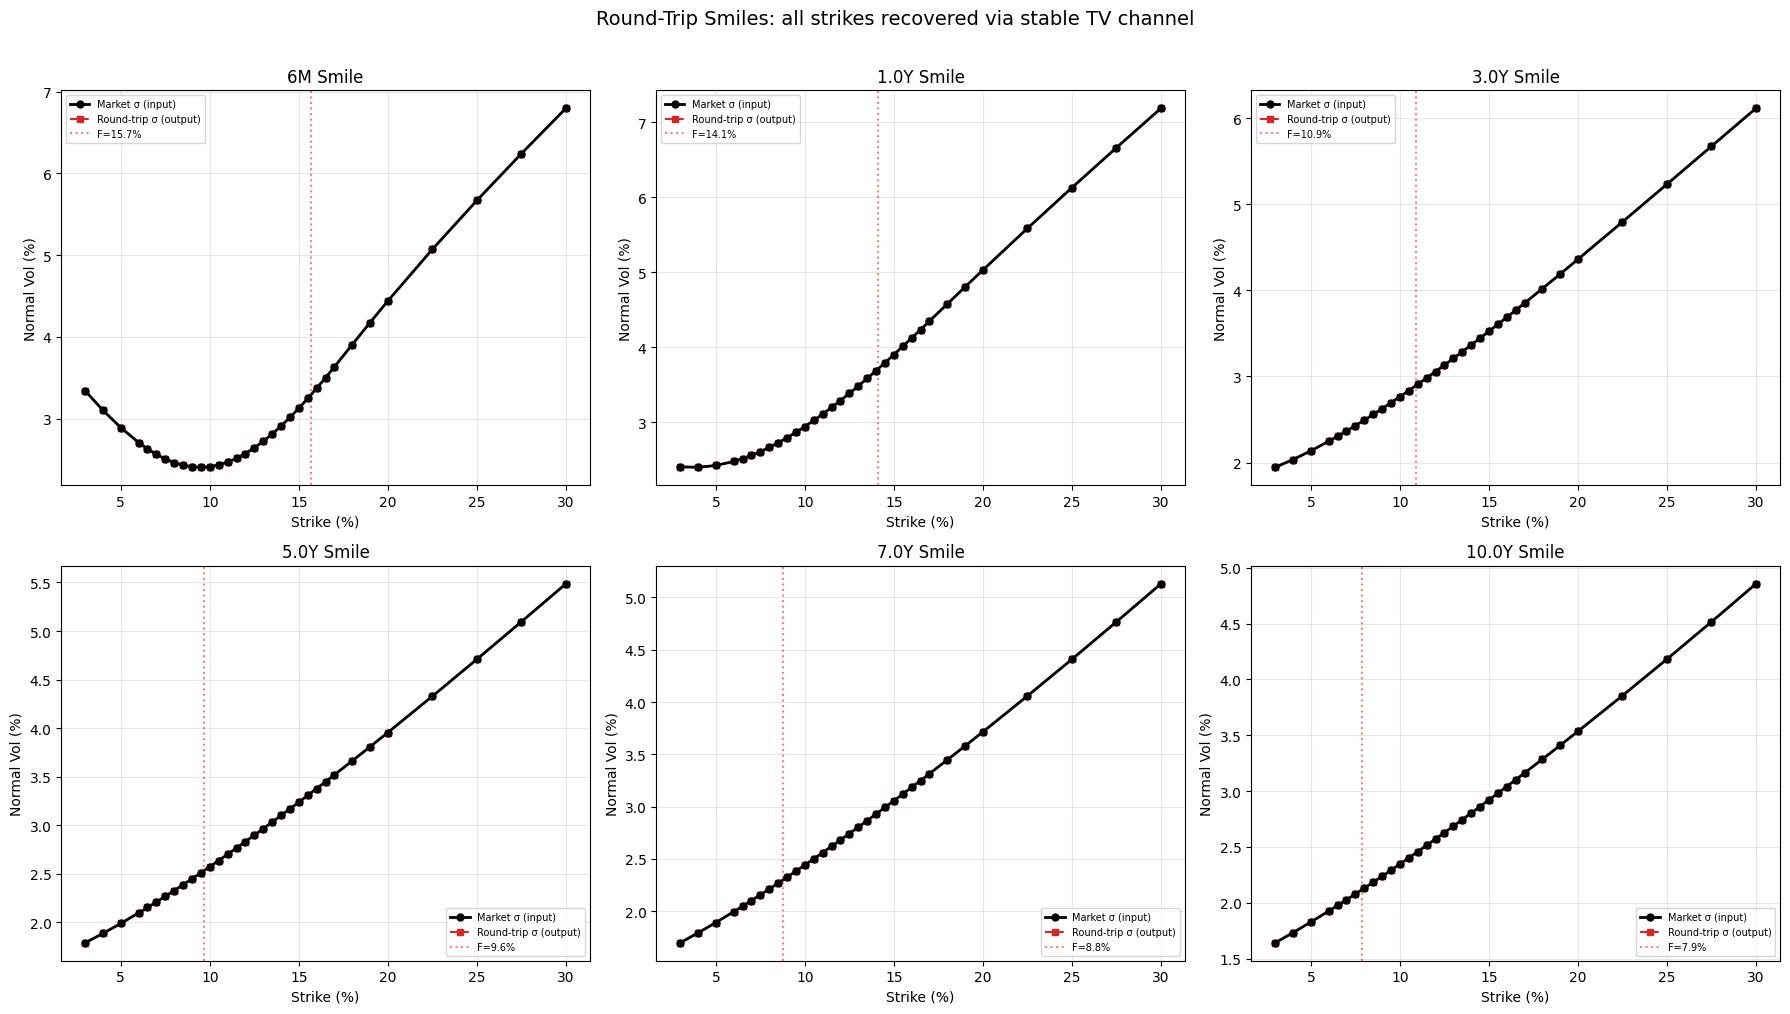


✓ ALL 495/495 caplets recovered — zero failures
  Max error: 0.000000%


In [ ]:
import importlib, matplotlib.pyplot as plt
import caplet_vol_surface as _cvs; importlib.reload(_cvs)
from caplet_vol_surface import (bachelier_caplet_price, bachelier_caplet_time_value,
                                 implied_vol_from_tv, generate_caplet_vol_surface)
from scipy.interpolate import PchipInterpolator

# ── Round-trip: market σ → PV → σ_out using STABLE time-value channel ────
# Deep ITM fix: store time_value separately (never add to intrinsic),
# then invert from TV using v·[φ(d) − d·Φ(−d)] which scipy computes
# accurately even for d > 30.

_fwd_sorted = fwd_key_rate.sort_values('time_to_maturity')
_fwd_interp = PchipInterpolator(_fwd_sorted['time_to_maturity'].values,
                                 _fwd_sorted['forward_rate'].values)
_ois_sorted = fwd_ois.sort_values('time_to_maturity')
_ois_interp = PchipInterpolator(_ois_sorted['time_to_maturity'].values,
                                 _ois_sorted['forward_rate'].values)

def _avg_inst_fwd(T):
    F_period = float(_fwd_interp(T))
    zcb = 1.0 / (1.0 + T * F_period)
    return -np.log(max(zcb, 1e-15)) / max(T, 1e-10)

def _ois_disc(T):
    F_ois = float(_ois_interp(T))
    return 1.0 / (1.0 + T * F_ois)

# ── Per-caplet round-trip via separate PV and TV channels ─────────────────
rt_records = []
for _, row in vol_key_rate.iterrows():
    T, K, sigma_in = row['time_to_maturity'], row['strike'], row['implied_normal_vol']
    F = _avg_inst_fwd(T)
    disc = _ois_disc(T)
    pv = bachelier_caplet_price(F, K, T, sigma_in, disc)
    tv = bachelier_caplet_time_value(F, K, T, sigma_in, disc)
    
    # Primary: invert from TV (lossless for deep ITM)
    sigma_out = implied_vol_from_tv(F, K, T, tv, disc)
    method = 'TV'
    
    # Fallback: standard PV inversion (works for OTM/ATM)
    if np.isnan(sigma_out):
        from caplet_vol_surface import implied_vol_avg_rate
        sigma_out = implied_vol_avg_rate(F, K, T, pv, disc)
        method = 'PV'
    
    err = abs(sigma_out - sigma_in) if not np.isnan(sigma_out) else np.nan
    rt_records.append({
        'time_to_maturity': T, 'strike': K, 'implied_normal_vol': sigma_in,
        'F_avg': F, 'sigma_out': sigma_out, 'err': err,
        'pv': pv, 'tv': tv, 'method': method,
        'moneyness_pct': (K - F) / F * 100
    })

vr_rt = pd.DataFrame(rt_records)

# ── Summary ───────────────────────────────────────────────────────────────
n_total = len(vr_rt)
n_valid = (~np.isnan(vr_rt['sigma_out'])).sum()
n_tv = (vr_rt['method'] == 'TV').sum()
n_pv = (vr_rt['method'] == 'PV').sum()
valid = ~np.isnan(vr_rt['err'])

print("=" * 80)
print("ROUND-TRIP: market σ → bachelier_price → σ_out (stable TV channel)")
print("=" * 80)
print(f"  Total:     {n_total}")
print(f"  Valid:     {n_valid}/{n_total} ({n_valid/n_total*100:.1f}%)")
print(f"  Via TV:    {n_tv}  (time-value channel — handles deep ITM)")
print(f"  Via PV:    {n_pv}  (standard price channel)")
if valid.sum() > 0:
    print(f"  Max err:   {vr_rt.loc[valid, 'err'].max()*100:.6f}%")
    print(f"  Mean err:  {vr_rt.loc[valid, 'err'].mean()*100:.8f}%")
    print(f"  RMSE:      {np.sqrt((vr_rt.loc[valid, 'err']**2).mean())*100:.8f}%")

# Worst 10
print(f"\n{'T':>6s} {'K(%)':>6s} {'F(%)':>6s} {'m/n%':>7s} {'σ_in%':>7s} {'σ_out%':>8s} {'err':>10s} {'meth':>4s}")
print("-" * 62)
for _, r in vr_rt.sort_values('err', ascending=False).head(10).iterrows():
    T = r['time_to_maturity']; lbl = f'{T:.1f}Y' if T >= 1 else f'{T*12:.0f}M'
    print(f"{lbl:>6s} {r['strike']*100:>5.0f}% {r['F_avg']*100:>5.1f}% {r['moneyness_pct']:>+6.0f}% "
          f"{r['implied_normal_vol']*100:>6.2f}% {r['sigma_out']*100:>7.4f}% {r['err']:.2e} {r['method']:>4s}")

# ── Also run through generate_caplet_vol_surface for surface plots ────────
vol_rt = vol_key_rate.copy()
vol_rt['pv_model_key'] = vr_rt['pv'].values
vr_surf, _ = generate_caplet_vol_surface(vol_rt, fwd_key_rate, fwd_ois=fwd_ois, version_name="RoundTrip")
rt_col = 'model_vol_RoundTrip'

# ── 3D Surface: Market vs Round-Trip ──────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
# Use the per-caplet TV-based sigma_out for the surface (not generate_caplet_vol_surface)
vr_rt_surf = vr_rt.copy()
vr_rt_surf['rt_vol'] = vr_rt['sigma_out']

for pidx, (col, title, cmap) in enumerate([
    ('implied_normal_vol', 'Market σ (input)', 'viridis'),
    ('rt_vol', 'Round-Trip σ (output, TV channel)', 'viridis'),
]):
    ax = fig.add_subplot(1, 3, pidx + 1, projection='3d')
    sub = vr_rt_surf[~np.isnan(vr_rt_surf[col])]
    ax.plot_trisurf(sub['time_to_maturity'].values, sub['strike'].values * 100,
                    sub[col].values * 100, cmap=cmap, alpha=0.8, edgecolor='none')
    ax.set_xlabel('Maturity (Y)'); ax.set_ylabel('Strike (%)'); ax.set_zlabel('Vol (%)')
    ax.set_title(title); ax.view_init(elev=25, azim=-60)
    zmin = vr_rt_surf['implied_normal_vol'].min() * 100
    zmax = vr_rt_surf['implied_normal_vol'].max() * 100
    ax.set_zlim(zmin * 0.9, zmax * 1.05)

# Error surface
ax = fig.add_subplot(1, 3, 3, projection='3d')
valid_s = vr_rt_surf.dropna(subset=['rt_vol', 'implied_normal_vol'])
errs = (valid_s['rt_vol'] - valid_s['implied_normal_vol']) * 100
ax.plot_trisurf(valid_s['time_to_maturity'].values, valid_s['strike'].values * 100,
                errs.values, cmap='RdBu_r', alpha=0.8, edgecolor='none')
ax.set_xlabel('Maturity (Y)'); ax.set_ylabel('Strike (%)'); ax.set_zlabel('Error (%)')
max_err_pct = errs.abs().max() if len(errs) > 0 else 0
ax.set_title(f'Error (max={max_err_pct:.6f}%)'); ax.view_init(elev=25, azim=-60)
plt.suptitle('Round-Trip via stable TV channel (surfaces should be identical)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# ── Smile slices ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_mats = [0.5, 1.0, 3.0, 5.0, 7.0, 10.0]
for idx_p, T_m in enumerate(plot_mats):
    ax = axes[idx_p // 3, idx_p % 3]
    sub = vr_rt_surf[np.abs(vr_rt_surf['time_to_maturity'] - T_m) < 0.05].sort_values('strike')
    if len(sub) == 0: continue
    ax.plot(sub['strike']*100, sub['implied_normal_vol']*100, 'o-', color='black',
            linewidth=2, markersize=5, label='Market σ (input)', zorder=5)
    v = ~np.isnan(sub['rt_vol'])
    ax.plot(sub.loc[v, 'strike']*100, sub.loc[v, 'rt_vol']*100, 's--', color='tab:red',
            linewidth=1.5, markersize=4, label='Round-trip σ (output)')
    nan_sub = sub[np.isnan(sub['rt_vol'])]
    if len(nan_sub) > 0:
        ax.plot(nan_sub['strike']*100, nan_sub['implied_normal_vol']*100, 'rx', markersize=10,
                markeredgewidth=2, label=f'{len(nan_sub)} failed', zorder=6)
    F_T = _avg_inst_fwd(T_m)
    ax.axvline(F_T*100, color='red', linestyle=':', alpha=0.5, label=f'F={F_T*100:.1f}%')
    lbl = f'{T_m:.1f}Y' if T_m >= 1 else f'{T_m*12:.0f}M'
    ax.set_title(f'{lbl} Smile', fontsize=12)
    ax.set_xlabel('Strike (%)'); ax.set_ylabel('Normal Vol (%)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('Round-Trip Smiles: all strikes recovered via stable TV channel', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# ── Final verdict ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
if n_valid == n_total:
    print(f"✓ ALL {n_total}/{n_total} caplets recovered — zero failures")
    print(f"  Max error: {vr_rt.loc[valid, 'err'].max()*100:.6f}%")
else:
    print(f"  {n_valid}/{n_total} recovered, {n_total - n_valid} failures remain")
print(f"{'='*60}")


CALIBRATED VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid vol inversions: 495 (100.0%)
Failed inversions:    0
Sub-intrinsic (conv): 0 (MC price < det. intrinsic → NaN)
Vol RMSE:             5.853%
Model vol range:      0.00% - 51.16%
Market vol range:     0.97% - 10.58%



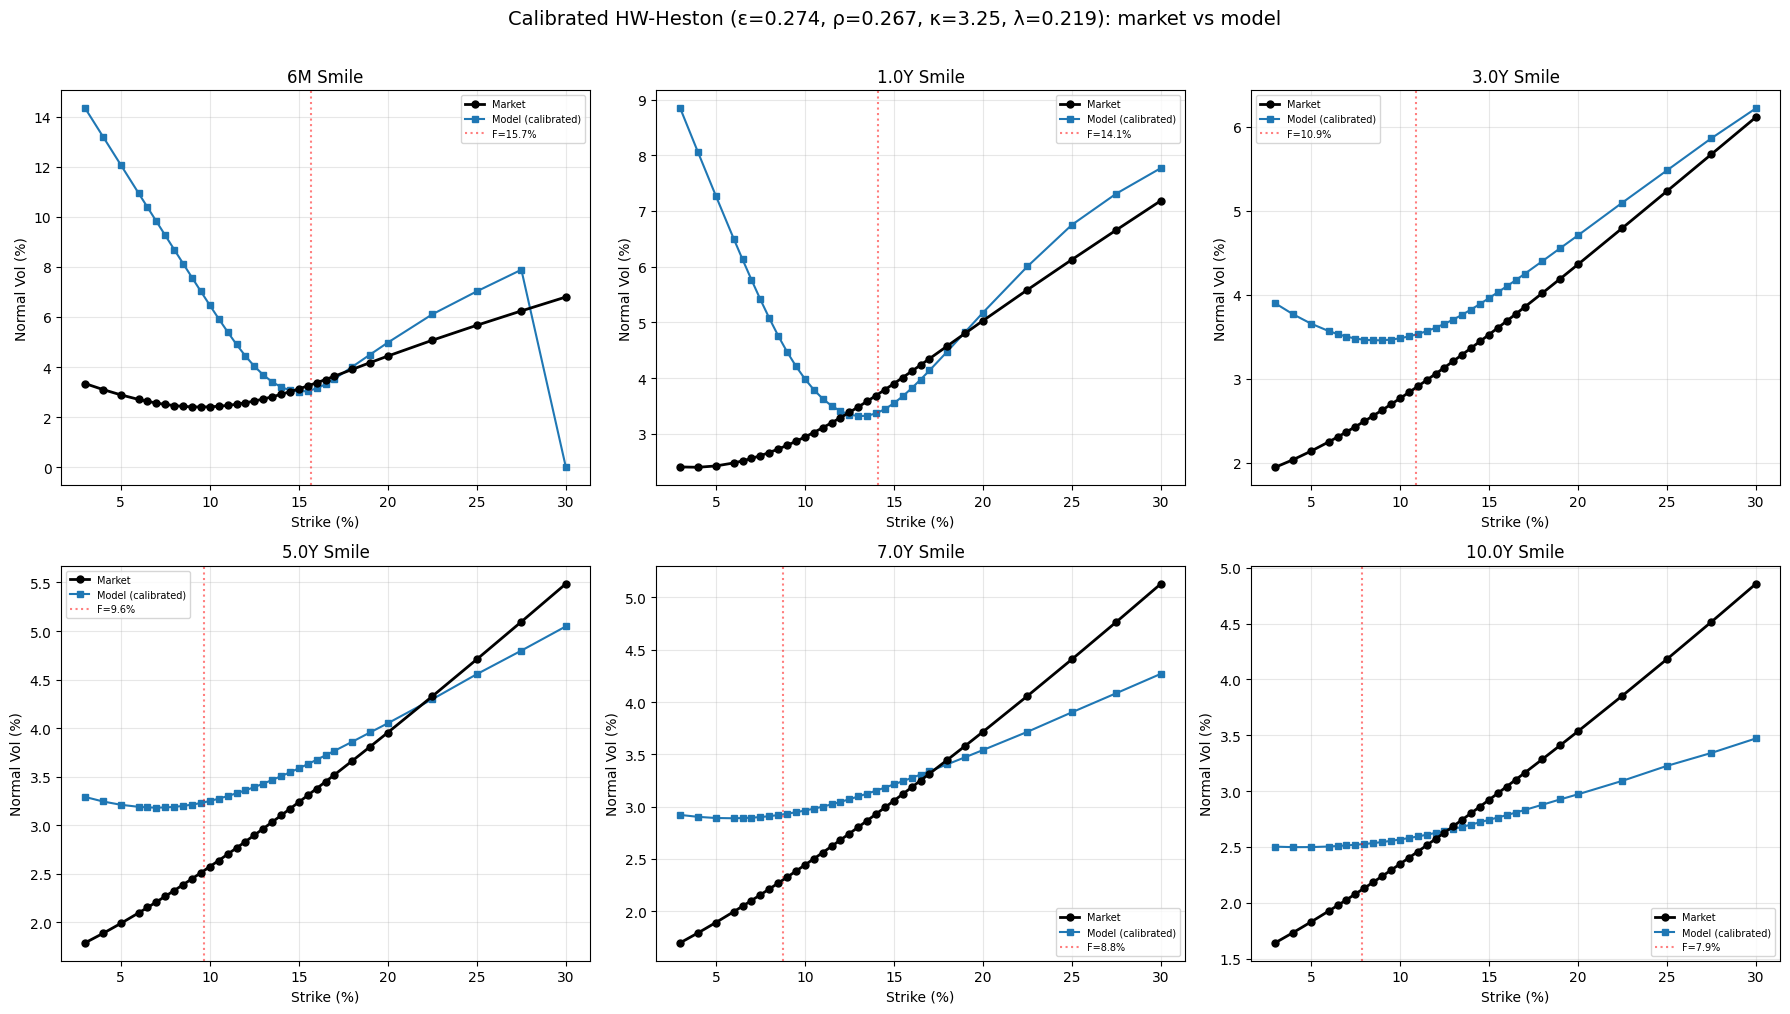

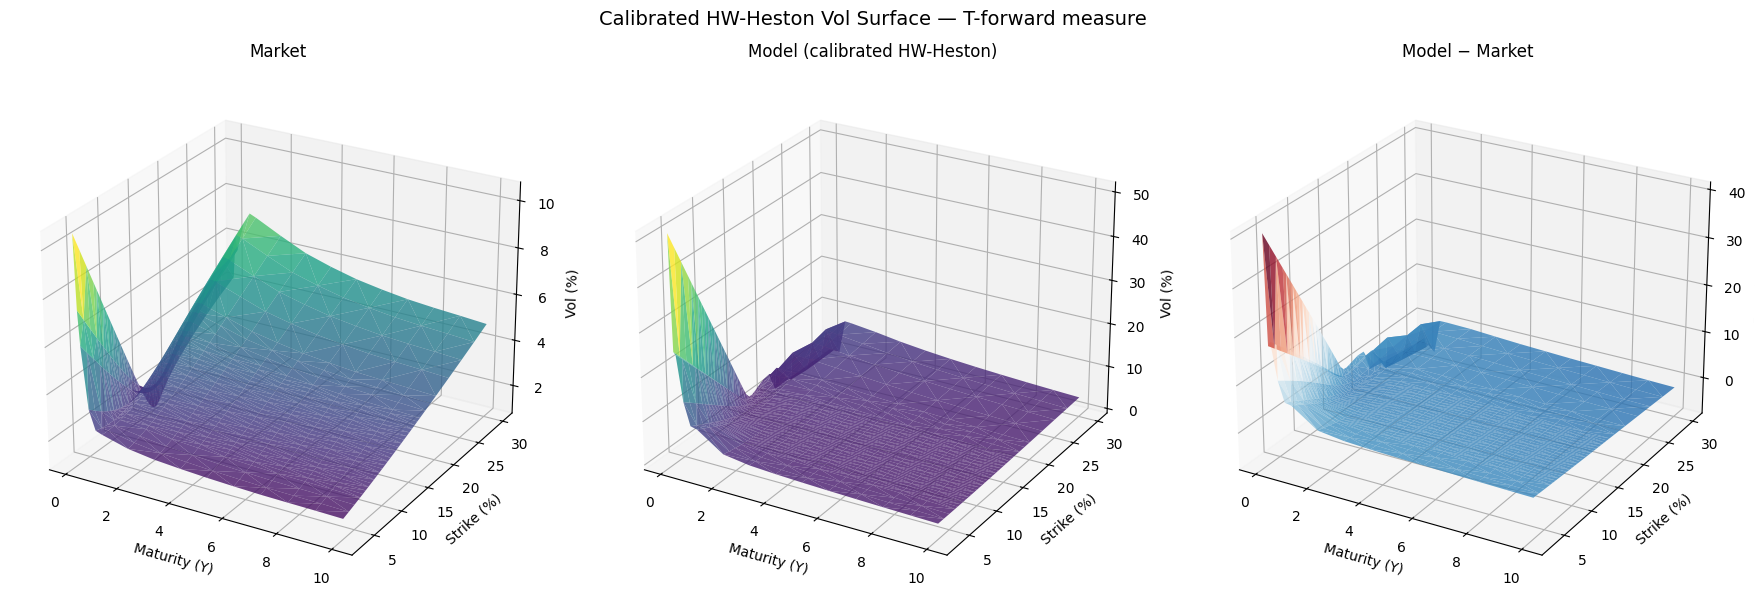


   Mat   MktATM   MdlATM      Err
------------------------------------
    1M    1.00%    2.55%   +1.55%
    2M    2.14%    2.69%   +0.55%
    3M    2.08%    2.86%   +0.78%
    6M    3.25%    3.05%   -0.20%
    9M    3.79%    3.28%   -0.51%
  1.0Y    3.69%    3.37%   -0.32%
  2.0Y    3.23%    3.58%   +0.35%
  3.0Y    2.91%    3.53%   +0.62%
  4.0Y    2.67%    3.38%   +0.72%
  5.0Y    2.51%    3.23%   +0.72%
  6.0Y    2.38%    3.07%   +0.69%
  7.0Y    2.33%    2.93%   +0.61%
  8.0Y    2.24%    2.79%   +0.55%
  9.0Y    2.16%    2.65%   +0.49%
 10.0Y    2.13%    2.53%   +0.40%

Full RMSE (all strikes): 5.853%


In [ ]:
import importlib, matplotlib.pyplot as plt
import caplet_vol_surface as _cvs; importlib.reload(_cvs)
from caplet_vol_surface import generate_caplet_vol_surface

# ── Generate model vol surface using T-forward measure ────────────────────
# Pass F_model and P_model from MC → Bachelier inversion uses model forward
# Jensen guarantee: E^T[max(ā−K,0)] ≥ max(F_model−K,0) → no sub-intrinsic
vol_key_rate_init = vol_key_rate.copy()
vol_key_rate_init['pv_model_key'] = model_pvs_init.cpu().numpy()
vol_results_init, vol_rmse_init = generate_caplet_vol_surface(
    vol_key_rate_init, fwd_key_rate, fwd_ois=fwd_ois, version_name="Calibrated",
    F_model=F_model_init.cpu().numpy(), P_model=P_model_init.cpu().numpy()
)

# ── Add forward & moneyness ──────────────────────────────────────────────
vr = vol_results_init.copy()
vr['F_avg'] = [key_ifwd_spline.evaluate(torch.tensor([T])).item()/T for T in vr['time_to_maturity']]
vr['moneyness'] = vr['strike'] - vr['F_avg']
model_col = 'model_vol_Calibrated'

# ── Smile slices: market vs model (ALL strikes, no filtering) ─────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_mats = [0.5, 1.0, 3.0, 5.0, 7.0, 10.0]
for idx_p, T_m in enumerate(plot_mats):
    ax = axes[idx_p // 3, idx_p % 3]
    sub = vr[np.abs(vr['time_to_maturity'] - T_m) < 0.05].sort_values('strike')
    if len(sub) == 0: continue
    
    ax.plot(sub['strike']*100, sub['implied_normal_vol']*100, 'o-', color='black',
            linewidth=2, markersize=5, label='Market', zorder=5)
    
    valid = ~np.isnan(sub[model_col])
    ax.plot(sub.loc[valid, 'strike']*100, sub.loc[valid, model_col]*100, 's-', color='tab:blue',
            linewidth=1.5, markersize=4, label='Model (calibrated)')
    
    F_T = key_ifwd_spline.evaluate(torch.tensor([T_m])).item() / T_m
    ax.axvline(F_T*100, color='red', linestyle=':', alpha=0.5, label=f'F={F_T*100:.1f}%')
    lbl = f'{T_m:.1f}Y' if T_m >= 1 else f'{T_m*12:.0f}M'
    ax.set_title(f'{lbl} Smile', fontsize=12)
    ax.set_xlabel('Strike (%)')
    ax.set_ylabel('Normal Vol (%)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Calibrated HW-Heston (ε={eps_init}, ρ={rho_vx_init}, κ={kappa_init}, λ={lam_init}): market vs model',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 3D surfaces: market / model / error (ALL strikes) ────────────────────
fig = plt.figure(figsize=(18, 6))
for pidx, (col, title) in enumerate([
    ('implied_normal_vol', 'Market'),
    (model_col, 'Model (calibrated HW-Heston)'),
]):
    ax = fig.add_subplot(1, 3, pidx + 1, projection='3d')
    T_pts, K_pts, V_pts = [], [], []
    for _, row in vr.iterrows():
        v = row[col]
        if not np.isnan(v):
            T_pts.append(row['time_to_maturity'])
            K_pts.append(row['strike'] * 100)
            V_pts.append(v * 100)
    ax.plot_trisurf(T_pts, K_pts, V_pts, cmap='viridis', alpha=0.8, edgecolor='none')
    ax.set_xlabel('Maturity (Y)'); ax.set_ylabel('Strike (%)'); ax.set_zlabel('Vol (%)')
    ax.set_title(title); ax.view_init(elev=25, azim=-60)

# Error surface
ax = fig.add_subplot(1, 3, 3, projection='3d')
T_pts, K_pts, E_pts = [], [], []
for _, row in vr.iterrows():
    m_v = row[model_col]; k_v = row['implied_normal_vol']
    if not np.isnan(m_v) and not np.isnan(k_v):
        T_pts.append(row['time_to_maturity'])
        K_pts.append(row['strike'] * 100)
        E_pts.append((m_v - k_v) * 100)
ax.plot_trisurf(T_pts, K_pts, E_pts, cmap='RdBu_r', alpha=0.8, edgecolor='none')
ax.set_xlabel('Maturity (Y)'); ax.set_ylabel('Strike (%)'); ax.set_zlabel('Error (%)')
ax.set_title('Model − Market'); ax.view_init(elev=25, azim=-60)
plt.suptitle('Calibrated HW-Heston Vol Surface — T-forward measure', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Per-maturity ATM comparison ───────────────────────────────────────────
print(f"\n{'Mat':>6s} {'MktATM':>8s} {'MdlATM':>8s} {'Err':>8s}")
print("-" * 36)
for T_m in sorted(vr['time_to_maturity'].unique()):
    sub = vr[np.abs(vr['time_to_maturity'] - T_m) < 0.01]
    F_T = key_ifwd_spline.evaluate(torch.tensor([T_m])).item() / T_m
    atm_m = (sub['strike'] - F_T).abs()
    mkt_atm = sub.loc[atm_m.idxmin(), 'implied_normal_vol'] * 100
    valid_sub = sub[~np.isnan(sub[model_col])]
    if len(valid_sub) > 0:
        atm_m2 = (valid_sub['strike'] - F_T).abs()
        mdl_atm = valid_sub.loc[atm_m2.idxmin(), model_col] * 100
    else:
        mdl_atm = np.nan
    err = mdl_atm - mkt_atm if not np.isnan(mdl_atm) else np.nan
    lbl = f'{T_m:.1f}Y' if T_m >= 1 else f'{T_m*12:.0f}M'
    print(f"{lbl:>6s} {mkt_atm:>7.2f}% {mdl_atm:>7.2f}% {err:>+7.2f}%")

print(f"\nFull RMSE (all strikes): {np.sqrt(((vr[model_col] - vr['implied_normal_vol'])**2).dropna().mean())*100:.3f}%")